In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
def housing_data_reader(filename='./data/housing_price.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['MEDV'],axis = 1)
    y =  data['MEDV']
    return X, y

def heart_disease_data_reader(filename='./data/Heart_disease_cleveland_new.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['target'],axis = 1)
    y =  data['target']
    return X, y

def h1n1_data_reader(filename='./data/process_data.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['h1n1_vaccine','respondent_id','seasonal_vaccine'],axis = 1)
    y =  data['h1n1_vaccine']
    return X, y

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import seaborn as sns
import networkx as nx

# plot the networkx graph for W and W_new
def plot_graph(W, file_name=None):
    """_summary_

    Args:
        W (pd.DataFrame): weight matrix
    """
    G = nx.Graph(W)
    plt.figure(figsize=(5, 5))
    nx.draw_shell(G, with_labels=True)
    if file_name is not None:
        plt.savefig(file_name, format='eps', dpi=300)
    plt.show()

In [10]:
# import shapG and necessary libraries
import networkx as nx
import seaborn as sns
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import pearsonr,kendalltau,spearmanr
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('.'), '..')))
import shapG.shapley as shapley
import shapG.plot as shapGplot
from shapG.utils import corr_generator, create_minimal_edge_graph, matrix_generator, kl, kl_mi_matrix
from shapG.lasso import *
from shapG.mst import *
from shapG.mst_graph import *

In [11]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import r2_score
# define the characteristic function
def classification_kpi(G,S):
    """_summary_

    Args:
        G (nx.Graph): _description_
        S (list): list of nodes (list of columns)
    """
    cols = list(S)
    if len(cols) == 0:
        return 0
    else:
        X_train, X_test, y_train, y_test = train_test_split(X_h1n1[cols], y_h1n1, test_size=0.2, random_state=42)
        lgb_model = lgb.LGBMRegressor(learning_rate=0.2, verbosity=-1)

        lgb_model.fit(X_train,y_train)
        lgb_pred = lgb_model.predict(X_test)
        r2 = r2_score(y_test, lgb_pred)
        return r2

[mst_knn2] edges selected: 104


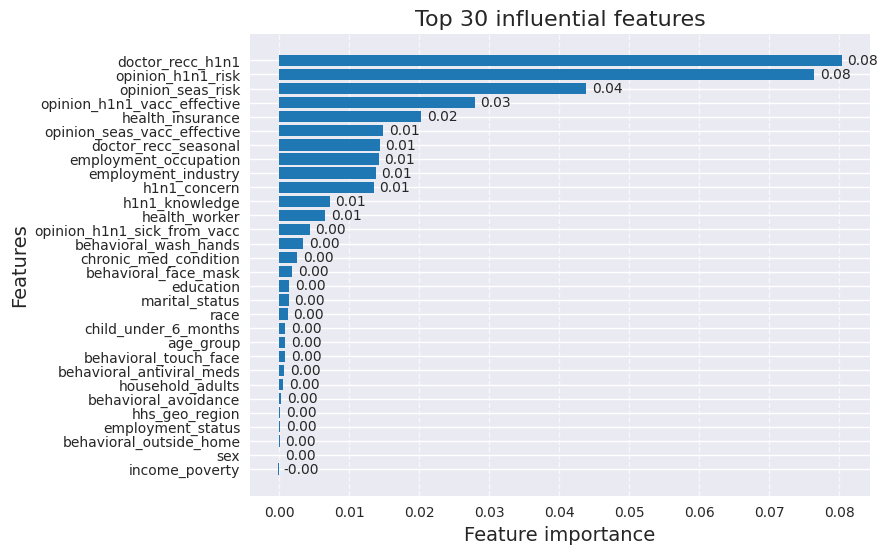

In [ ]:
# explain the model
X_h1n1, y_h1n1 = h1n1_data_reader('./data/process_data.csv')
W_h1n1 = matrix_generator_mst(X_h1n1, pearsonr)
A_h1n1, W_new_h1n1 = create_minimal_edge_graph_mst(W_h1n1, version='mst', verbose=True)
G_h1n1 = nx.Graph(A_h1n1)
shapley_value_h1n1 = shapley.shapG(
    G_h1n1,
    m=5,
    f=classification_kpi,
    approximate_by_ratio=True
)
fig_mst, ax_mst = shapGplot(shapley_value_h1n1, top_n=30, show_plot=False)
ax_mst.set_xlabel("Feature importance", fontsize=14)
ax_mst.set_ylabel("Features", fontsize=14)
ax_mst.spines['top'].set_visible(False)
ax_mst.spines['right'].set_visible(False)
ax_mst.set_title('Top 30 influential features', fontsize=16)
plt.show()

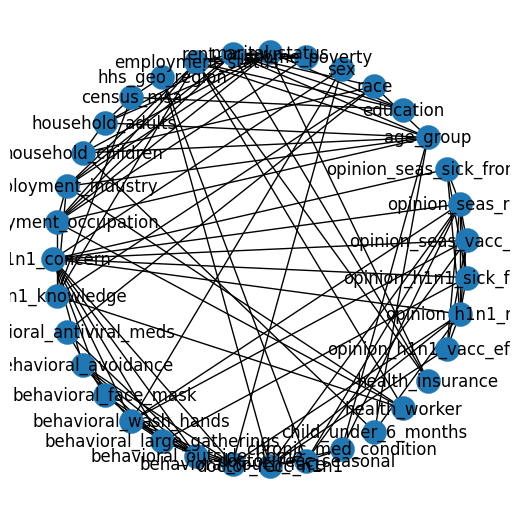

In [23]:
plot_graph(W_new_h1n1, file_name=None)

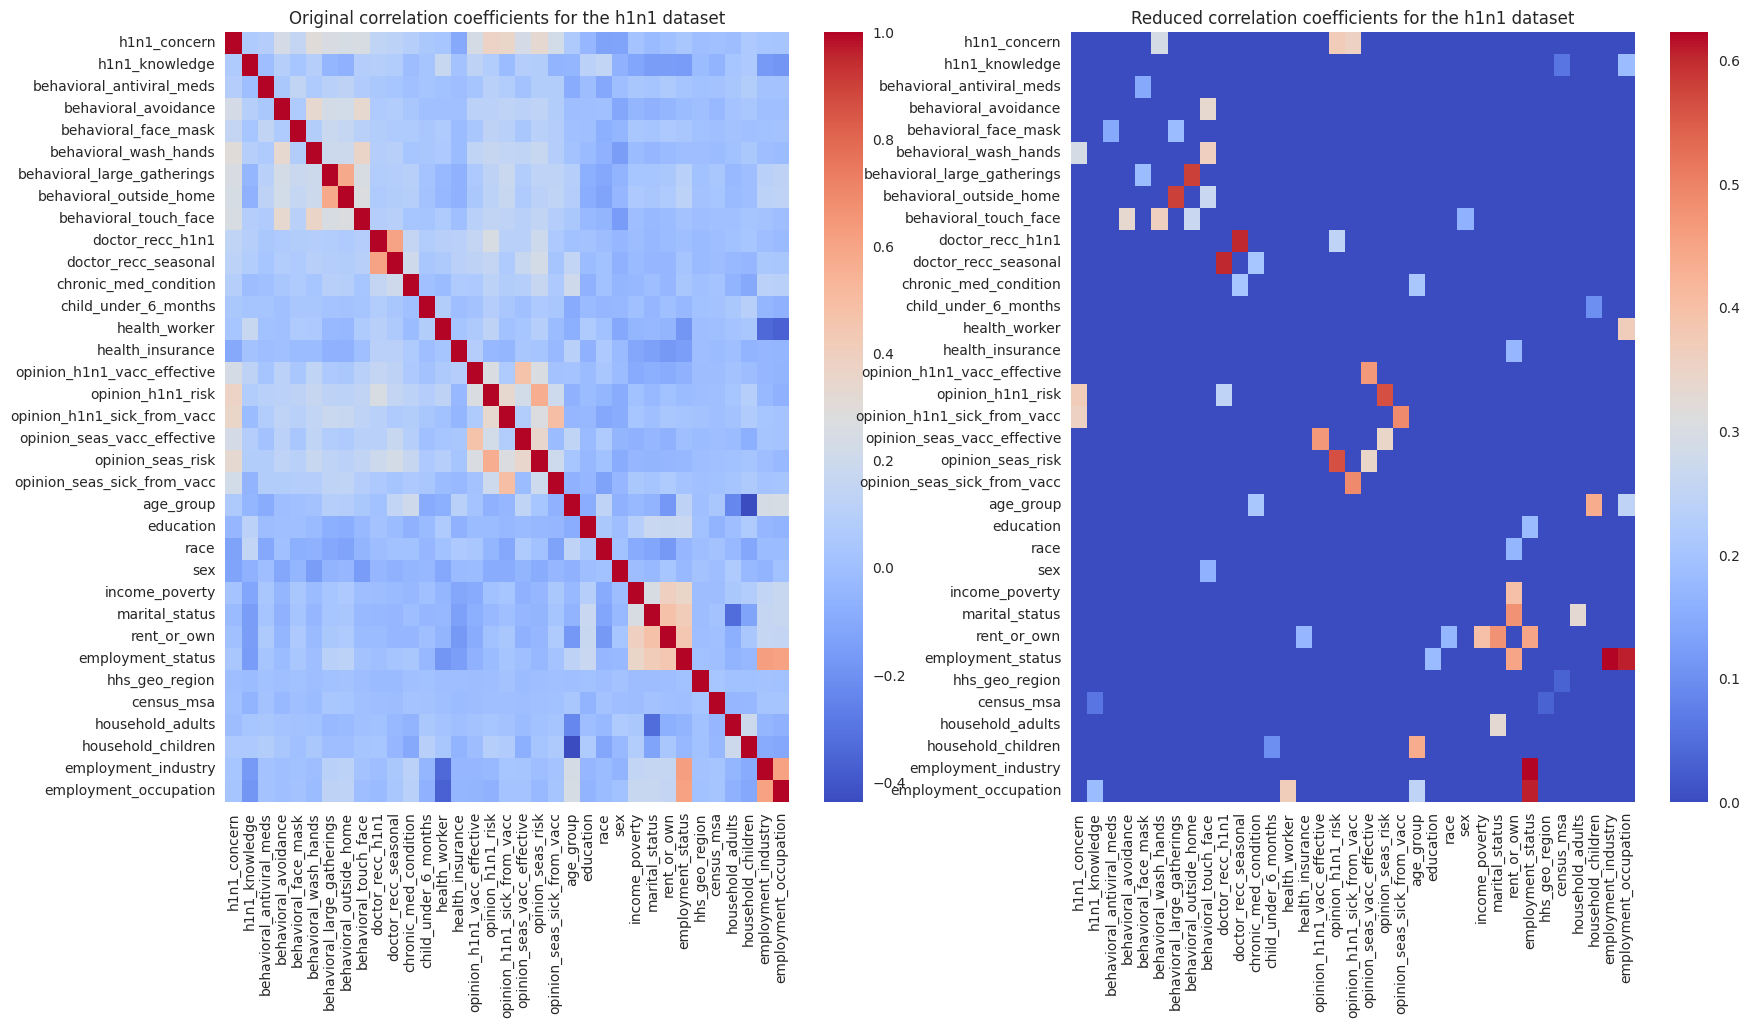

In [20]:
# create two heatmaps for W and W_new
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
sns.heatmap(W_h1n1, annot=False, cmap='coolwarm', cbar=True)
plt.title('Original correlation coefficients for the h1n1 dataset')
plt.subplot(1, 2, 2)
sns.heatmap(W_new_h1n1, annot=False, cmap='coolwarm', cbar=True)
plt.title('Reduced correlation coefficients for the h1n1 dataset')
# plt.savefig('housing-heatmap.eps', format='eps', dpi=300)

plt.show()

In [17]:
import xgboost

import shap

# train XGBoost model
X_vac_shap, y_vac_shap = h1n1_data_reader(filename='./data/process_data.csv')
model = lgb.LGBMRegressor(learning_rate=0.2, verbosity=-1).fit(X_vac_shap, y_vac_shap)
# compute SHAP values
explainer = shap.Explainer(model, X_vac_shap)
shap_values = explainer(X_vac_shap)

 99%|===================| 26515/26707 [01:06<00:00]        

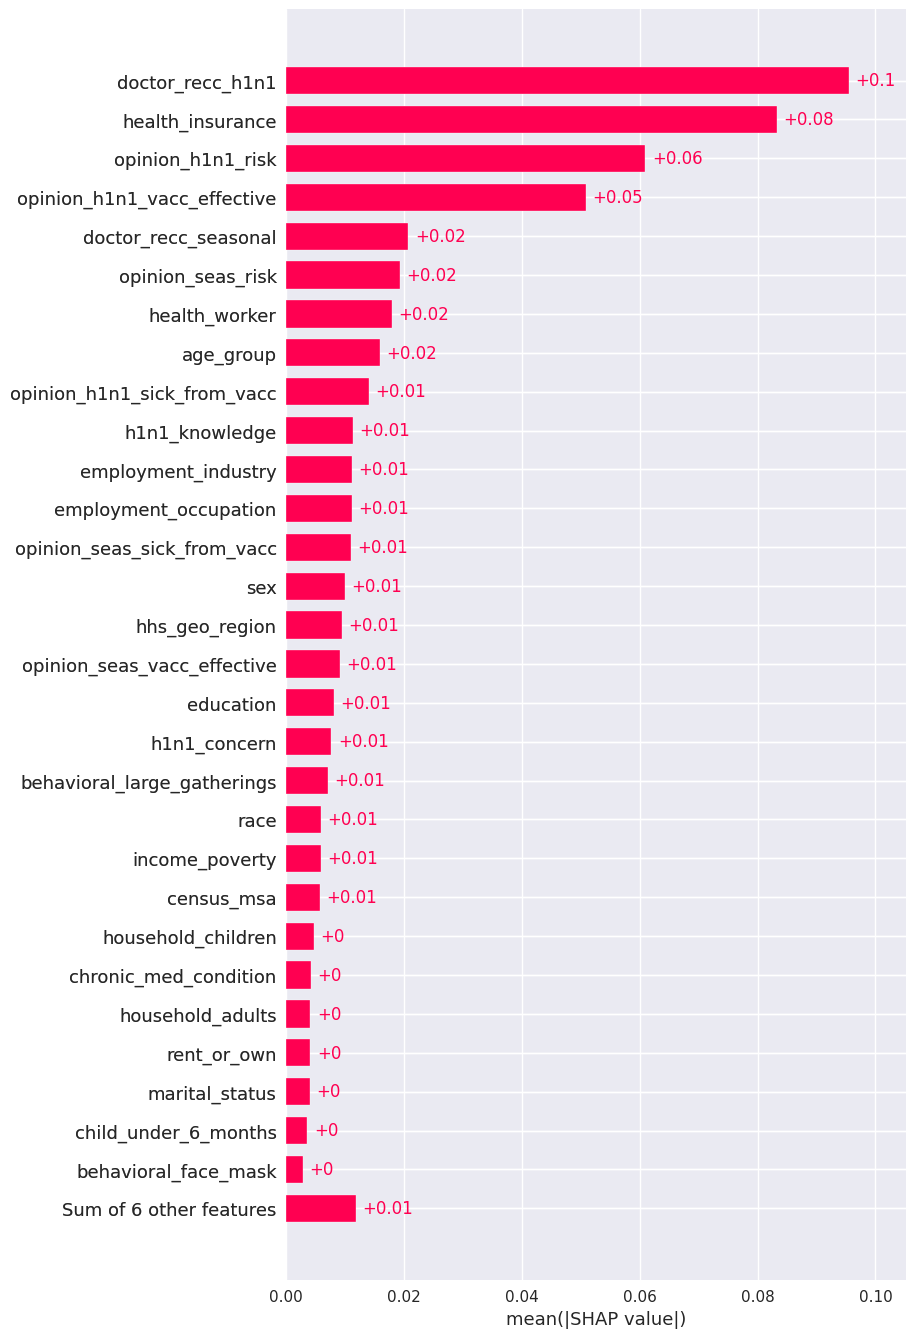

In [18]:
shap.plots.bar(shap_values, max_display=30)